# 2024-001 D31 Takedown Analysis

The following R notebook describes analysis steps for D31 spleen data.

## Initialize environment

Load packages needed for analysis.

**Note!** This notebook uses a frozen version of **fcexpr** (*dsalbao/fcexpr*) that was forked from *close-your-eyes*'s GitHub repository (*close-your-eyes/fcexpr*). The updated version does not support the commands used in this notebook.

In [1]:
# Load R Packages
library(fcexpr) # Reads FlowJo Workspace files
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load FlowJo Workspace

In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig02")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "2024-001-Runx3DeDiff.wsp",
                rds_file = "2024-001-Runx3DeDiff.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts
counts <- workspace[["counts"]]

# Preview
head(counts)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,FractionOfParent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,lymphnode.fcs,root,NA,root,111,NA,NA,NA,NA,NA,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp
2,lymphnode.fcs,mock,root,NA/mock,62,111,0.55855856,Comp-BV421-A,Comp-BUV496-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp
3,lymphnode.fcs,Runx3,root,NA/Runx3,38,111,0.34234234,Comp-BV421-A,Comp-BUV496-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp
4,lymphnode.fcs,White,root,NA/White,92,111,0.82882883,Comp-APC-A,Comp-BUV 396-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp
5,lymphnode.fcs,mock/CD62L+,mock,mock/CD62L+,5,62,0.08064516,Comp-PE-Cy7-A,Comp-GFP-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp
6,lymphnode.fcs,mock/Double,mock,mock/Double,22,62,0.35483871,Comp-GFP-A,Comp-BUV737-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/lymphnode.fcs,Concatenate,260812-Analysis.wsp


## Data Cleaning

Steps outlined here are to clean data before analysis. I will only be interested in transferred cells in this analysis, therefore, I will only retain cells that contain the *Transferred* gate. Moreover, I only want to retain groups containing experimental samples, so retain groups labelled *Spleen* and *Lymph*.

In [3]:
# Isolate Transferred populations and samples within the Spleen And Lymph groups
counts <- counts[ grepl("Transferred/", counts$PopulationFullPath) & 
                  counts$FlowJoGroup %in% c("Spleen", "Lymph"), ]

# Preview
head(counts)

,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,FractionOfParent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
104,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred,mock,14,23,0.6086957,Comp-BV421-A,Comp-BUV496-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp
105,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/Runx3,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred,Runx3,9,23,0.3913043,Comp-BV421-A,Comp-BUV496-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp
106,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock/CD62L+,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock,mock/CD62L+,0,14,0.0000000,Comp-PE-Cy7-A,Comp-GFP-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp
107,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock/DP,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock,mock/DP,5,14,0.3571429,Comp-PE W_561-A,Comp-BUV737-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp
108,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock/EE,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock,mock/EE,0,14,0.0000000,Comp-PE W_561-A,Comp-BUV737-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp
109,LymphNodes_LN1.fcs,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock/MP,Lymphocytes/Single Cells/Single Cells/Single Cells/Single Cells/CD8/Transferred/mock,mock/MP,3,14,0.2142857,Comp-PE W_561-A,Comp-BUV737-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-D31Spleen/LymphNodes_LN1.fcs,Lymph,260812-Analysis.wsp


In [4]:
# Remove unnecessary columns
counts <- counts[, c('FileName', 'FlowJoGroup', 'Population', 'Count', 'ParentCount', 'FractionOfParent')]
# Rename columns
colnames(counts) <- c('ID', 'Group', 'Population', 'Count', 'ParentCount', 'Percent')
# Compute percent
counts$Percent <- counts$Percent * 100

# Preview
head(counts)
write.csv(counts, "2024-001-counts.csv", row.names = FALSE)

,ID,Group,Population,Count,ParentCount,Percent
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
104,LymphNodes_LN1.fcs,Lymph,mock,14,23,60.86957
105,LymphNodes_LN1.fcs,Lymph,Runx3,9,23,39.13043
106,LymphNodes_LN1.fcs,Lymph,mock/CD62L+,0,14,0.00000
107,LymphNodes_LN1.fcs,Lymph,mock/DP,5,14,35.71429
108,LymphNodes_LN1.fcs,Lymph,mock/EE,0,14,0.00000
109,LymphNodes_LN1.fcs,Lymph,mock/MP,3,14,21.42857


### Cleanup

In [5]:
# Isolate Lymphnodes first and remove white pulp from the lymphnodes
counts_lymph <- counts %>% 
  filter(Group == "Lymph") %>% 
  filter(!grepl("White|Red", Population))

# Isolate Spleen next
counts_spleen <- counts %>% 
  filter(Group == "Spleen")

# From spleen, isolate white pulp
counts_white <- counts_spleen %>% 
  filter(grepl("White", Population))

# From the counts_white, replace the substring "/White" from the Population column,
# then replace "Spleen" as "WhitePulp" in the Group column
counts_white$Group <- gsub("Spleen", "WhitePulp", counts_white$Group)
counts_white$Population <- gsub("/White", "", counts_white$Population)

# Then remove the white pulp from the spleen
counts_spleen <- counts_spleen %>% 
  filter(!grepl("White|Red", Population))

# Save the different CSVs
write.csv(counts_lymph, "2024-001-counts_lymph.csv", row.names = FALSE)
write.csv(counts_spleen, "2024-001-counts_spleen.csv", row.names = FALSE)
write.csv(counts_white, "2024-001-counts_white.csv", row.names = FALSE)

# Recombine the counts
counts_clean <- rbind(counts_lymph, counts_spleen, counts_white)

# Rename the Group column as Tissue
counts_clean$Tissue <- counts_clean$Group
# Remove the Group column
counts_clean$Group <- NULL

# Population contains two pieces of information:
# Transduction/Population, seprarated by a "/"
# Separate them into the "Transduction" and "Population" columns
counts_clean <- counts_clean %>% 
  separate(Population, into = c("Transduction", "Population"), sep = "/")

# Rearrange the columns
counts_clean <- counts_clean[, c("ID", "Tissue", "Transduction", "Population", "Count", "ParentCount", "Percent")]

# Rename the ID
counts_clean$ID <- gsub(".fcs", "", counts_clean$ID)
counts_clean$ID <- gsub("Spleen_SP|LymphNodes_LN", "M", counts_clean$ID)

# Write the clean counts
write.csv(counts_clean, "2024-001-counts_combined.csv", row.names = FALSE)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 30 rows [1, 2, 37, 38,
73, 74, 109, 110, 145, 146, 181, 182, 217, 218, 253, 254, 289, 290, 325, 326,
...].”


In [6]:
# Factorize the Transduction and Tissue columns
counts_clean$Transduction <- factor(counts_clean$Transduction, levels = c("mock", "Runx3"))
counts_clean$Tissue <- factor(counts_clean$Tissue, levels = c("Spleen", "WhitePulp", "Lymph"))
# repalce + in the Population column with p
counts_clean$Population <- gsub("\\+", "p", counts_clean$Population)

### Plot mock - Runx3 De-Differentiation

In [7]:
# Keep only Tcf7p and Tcf7pCD62Lp populations
subset <- counts_clean %>% 
  filter(grepl("Tcf7p|Tcf7pCD62Lp", Population))

# Factorize the Population column
subset$Population <- factor(subset$Population, levels = c("Tcf7p", "Tcf7pCD62Lp"))

head(subset)

,ID,Tissue,Transduction,Population,Count,ParentCount,Percent
,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
112,M1,Lymph,mock,Tcf7p,1,14,7.142857
113,M1,Lymph,mock,Tcf7pCD62Lp,5,14,35.714286
131,M1,Lymph,Runx3,Tcf7p,1,9,11.111111
132,M1,Lymph,Runx3,Tcf7pCD62Lp,5,9,55.555556
197,M2,Lymph,mock,Tcf7p,5,17,29.411765
198,M2,Lymph,mock,Tcf7pCD62Lp,9,17,52.941176


In [8]:
# Keep only ID, Tissue, Transduction, Population, Percent
subset <- subset[, c("ID", "Tissue", "Transduction", "Population", "Percent")]

# Ragges apply mean on percent by Population, transduction and tissue
ragged <- subset %>% 
  group_by(Population, Transduction, Tissue) %>% 
  summarise(Percent = mean(Percent)) %>% 
  ungroup()

ragged

`summarise()` has grouped output by 'Population', 'Transduction'. You can
override using the `.groups` argument.


Population,Transduction,Tissue,Percent
<fct>,<fct>,<fct>,<dbl>
Tcf7p,mock,Spleen,19.116729
Tcf7p,mock,WhitePulp,56.531284
Tcf7p,mock,Lymph,27.054514
Tcf7p,Runx3,Spleen,61.795880
Tcf7p,Runx3,WhitePulp,54.595489
Tcf7p,Runx3,Lymph,28.623321
Tcf7pCD62Lp,mock,Spleen,3.659647
Tcf7pCD62Lp,mock,WhitePulp,32.810522
Tcf7pCD62Lp,mock,Lymph,32.932558


In [9]:
# Create a default theme
colors <- c("mock" = "#808180", "Runx3" = "#00A087")

# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans",
                        #base_fontface = "plain"
                        ) +
    theme(  axis.text = element_text(size = 10),
            axis.title = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12),
            axis.title.x = element_blank(),
            strip.text = element_text(size = 12),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

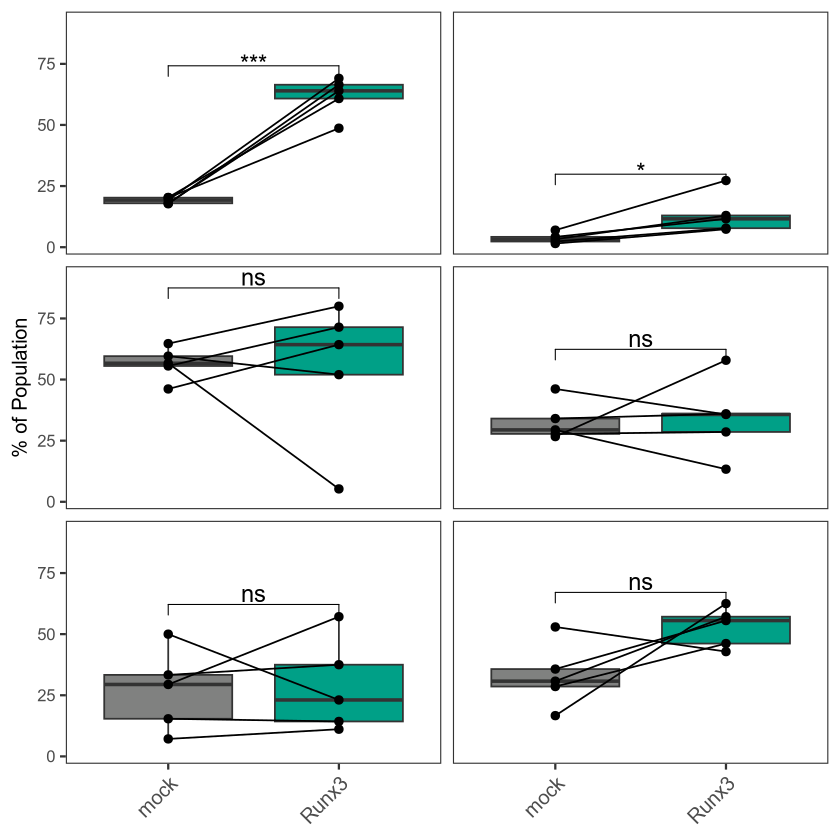

In [10]:
# Combine Tissue x Population into one facet variable so plot_padj() can
# compute a p-value per facet; strip labels are blank below, so this is
# visually identical to facet_wrap(~ Tissue + Population)
plot.data.df <- subset %>%
    mutate(facet = interaction(Tissue, Population, lex.order = TRUE)) %>%
    arrange(facet, ID)

# Calculate p-values and BH-adjusted p-values for mock vs. Runx3
plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = list(c("mock", "Runx3")),
    id_col = "ID",
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "facet",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2024-001-Fig02c.csv")

p <- ggplot(plot.data.df, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ facet, ncol = 2) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",
        tip.length = 0.05,
        size = 5,
        inherit.aes = FALSE
    ) + 
    ylim(c(min(subset$Percent) * 0.99, max(plot.stat.df$y.position, na.rm = TRUE) * 1.05)) +
    scale_fill_manual(values = colors) +
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

#pdf("Test2_280917Recompute.pdf")
print(p)
#dev.off()

In [11]:
# Save as PDF
pdf("2024-001-Fig02c.pdf", width = 2.5, height = 5)
print(p)
dev.off()

pdf 
  2

### Plot Gerlach Subsets

In [12]:
# Keep only Tcf7p and Tcf7pCD62Lp populations
subset <- counts_clean %>% 
  filter(Population %in% c("Tcm", "Tpm", "Tem"))

# Factorize the Population column
subset$Population <- factor(subset$Population, levels = c("Tcm", "Tpm", "Tem"))

head(subset)

,ID,Tissue,Transduction,Population,Count,ParentCount,Percent
,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
114,M1,Lymph,mock,Tcm,3,14,21.42857
118,M1,Lymph,mock,Tem,7,14,50.00000
121,M1,Lymph,mock,Tpm,4,14,28.57143
133,M1,Lymph,Runx3,Tcm,1,9,11.11111
137,M1,Lymph,Runx3,Tem,0,9,0.00000
140,M1,Lymph,Runx3,Tpm,7,9,77.77778


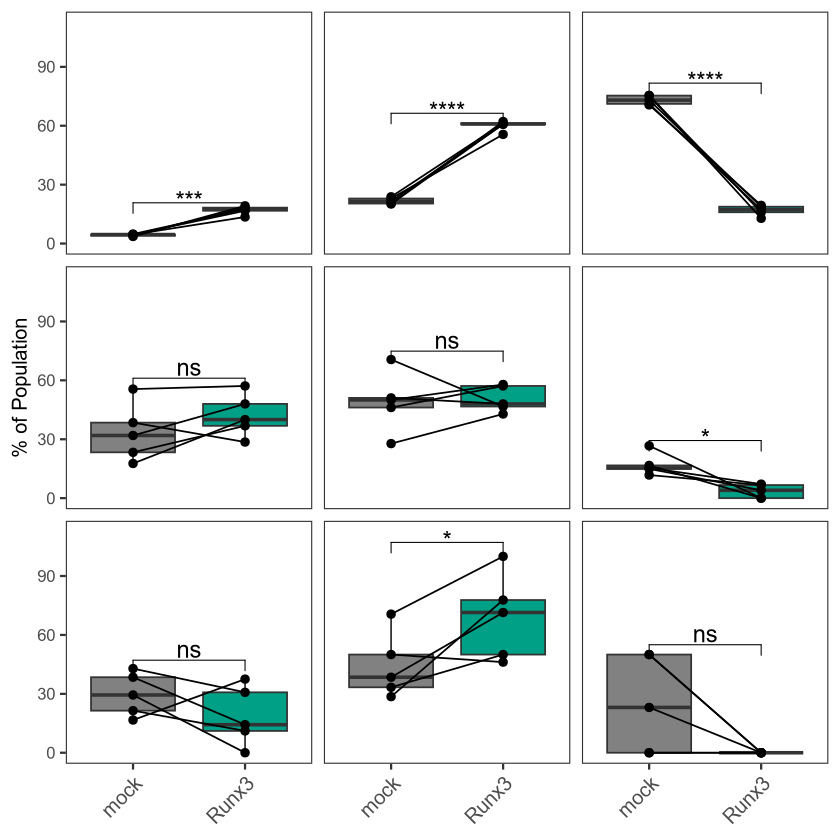

In [13]:
# Combine Tissue x Population into one facet variable so plot_padj() can
# compute a p-value per facet; strip labels are blank below, so this is
# visually identical to facet_wrap(~ Tissue + Population)
plot.data.df <- subset %>%
    mutate(facet = interaction(Tissue, Population, lex.order = TRUE)) %>%
    arrange(facet, ID)

# Calculate p-values and BH-adjusted p-values for mock vs. Runx3
plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = list(c("mock", "Runx3")),
    id_col = "ID",
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "facet",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2024-001-Fig02d.csv")

p <- ggplot(plot.data.df, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ facet, ncol = 3) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",
        tip.length = 0.05,
        size = 5,
        inherit.aes = FALSE
    ) + 
    ylim(c(min(subset$Percent) * 0.99, max(plot.stat.df$y.position, na.rm = TRUE) * 1.05)) +
    scale_fill_manual(values = colors) +
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

#pdf("GerlachTest_280917Recompute.pdf")
print(p)
#dev.off()

In [14]:
pdf("2024-001-Fig02d.pdf", width = 3, height = 5)
print(p)
dev.off()

pdf 
  2

In [15]:
# Combine Tissue x Transduction into one facet variable so plot_padj() can
# BH-correct the two comparisons within each facet; strip labels are blank
# below, so this is visually identical to facet_wrap(~ Tissue + Transduction)
plot.data.df <- subset %>%
    mutate(facet = interaction(Tissue, Transduction, lex.order = TRUE)) %>%
    arrange(facet, ID)

# Calculate p-values and BH-adjusted p-values for the Population comparisons
plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = list(c("Tpm", "Tcm"), c("Tem", "Tpm")),
    id_col = "ID",
    y_col = "Percent",
    x_col = "Population",
    facet_col = "facet",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2024-001-Fig02-unused.csv")

p <- ggplot(plot.data.df, aes(x = Population, y = Percent, fill = Population)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ facet, ncol = 2) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",
        tip.length = 0.05,
        size = 5,
        inherit.aes = FALSE
    ) + 
    ylim(c(min(subset$Percent) * 0.99, max(plot.stat.df$y.position, na.rm = TRUE) * 1.05)) +
    scale_fill_manual(values = c("Tcm" = "#1D2B53", "Tpm" = "#7E2553", "Tem" = "#FF004D")) +
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

pdf("2024-001-Fig02-unused.pdf", width = 3, height = 5)
print(p)
dev.off()

pdf 
  2

In [16]:
# Ragged apply mean on percent by Population, transduction and tissue
ragged <- subset %>% 
  group_by(Transduction, Tissue, Population) %>% 
  summarise(Percent = mean(Percent)) %>% 
  ungroup()
ragged

`summarise()` has grouped output by 'Transduction', 'Tissue'. You can override
using the `.groups` argument.


Transduction,Tissue,Population,Percent
<fct>,<fct>,<fct>,<dbl>
mock,Spleen,Tcm,4.324252
mock,Spleen,Tpm,21.757342
mock,Spleen,Tem,73.123256
mock,WhitePulp,Tcm,33.382476
mock,WhitePulp,Tpm,49.116738
mock,WhitePulp,Tem,17.075254
mock,Lymph,Tcm,29.765137
mock,Lymph,Tpm,44.190907
mock,Lymph,Tem,24.615385


### Plot Residence

In [17]:
# Keep only Tcf7p and Tcf7pCD62Lp populations
subset <- counts_clean %>% 
  filter(is.na(Population))

# We will need to recompute Percent for WhitePulp
# subset_white and remove WhitePulp from subset
subset_white <- subset %>% 
  filter(Tissue == "WhitePulp")
subset <- subset %>%
  filter(Tissue != "WhitePulp")

# Keep only ID, Tissue, Transduction, Count of subset_white
subset_white <- subset_white[, c("ID", "Tissue", "Transduction", "Count")]

# Spread Count by Transduction
subset_white <- subset_white %>% 
  pivot_wider(names_from = Transduction, values_from = Count)

# Compute mock % and Runx3 % per observation
subset_white$mock_percent <- subset_white$mock / (subset_white$mock + subset_white$Runx3) * 100
subset_white$Runx3_percent <- subset_white$Runx3 / (subset_white$mock + subset_white$Runx3) * 100

# Remove the mock and Runx3 columns
# Rename the mock_percent and Runx3_percent columns into mock and Runx3
subset_white <- subset_white[, c("ID", "Tissue", "mock_percent", "Runx3_percent")]
colnames(subset_white) <- c("ID", "Tissue", "mock", "Runx3")
# Gather the mock and Runx3 columns
subset_white <- subset_white %>% 
  pivot_longer(cols = c("mock", "Runx3"), names_to = "Transduction", values_to = "Percent")

# Remove Population, Count and ParentCount columns
subset <- subset[, c("ID", "Tissue", "Transduction", "Percent")]
# Recombine the counts
subset_combined <- rbind(subset, subset_white)

# Make subset_combined$Tissue a factor
subset_combined$Tissue <- as.character(subset_combined$Tissue)
subset_combined$Transduction <- as.character(subset_combined$Transduction)
subset_combined$Tissue <- factor(subset_combined$Tissue, levels = c("Spleen", "WhitePulp", "Lymph"))
subset_combined$Transduction <- factor(subset_combined$Transduction, levels = c("mock", "Runx3"))
subset_combined

,ID,Tissue,Transduction,Percent
,<chr>,<fct>,<fct>,<dbl>
104,M1,Lymph,mock,60.86957
105,M1,Lymph,Runx3,39.13043
189,M2,Lymph,mock,70.83333
190,M2,Lymph,Runx3,29.16667
274,M3,Lymph,mock,65.00000
275,M3,Lymph,Runx3,35.00000
359,M4,Lymph,mock,48.27586
360,M4,Lymph,Runx3,44.82759
444,M5,Lymph,mock,40.00000


Load day 14 blood data:

In [18]:
blood <- read.csv("BloodRatios.csv")

# Add Tissue Column equal to Blood
blood$Tissue <- "Blood"
# Gather last two columns into Transduction and Percent ( DO NOT gather Tissue)
blood <- blood %>%
    gather(key = "Transduction", value = "Percent", -ID, -Tissue)

blood

# Add blood to subset_combined
subset_combined <- rbind(subset_combined, blood)

# Rename WhitePulp as White Pulp
subset_combined$Tissue <- gsub("WhitePulp", "White Pulp", subset_combined$Tissue)
# Rename Lymph as Lymph Nodes
subset_combined$Tissue <- gsub("Lymph", "Lymph Nodes", subset_combined$Tissue)
# Factorize Tissue again
subset_combined$Tissue <- factor(subset_combined$Tissue, levels = c("Blood", "Spleen", "White Pulp", "Lymph Nodes"))

ID,Tissue,Transduction,Percent
<chr>,<chr>,<chr>,<dbl>
M1,Blood,mock,91.70
M2,Blood,mock,90.60
M3,Blood,mock,89.80
M4,Blood,mock,90.90
M5,Blood,mock,92.70
M1,Blood,Runx3,8.33
M2,Blood,Runx3,9.43
M3,Blood,Runx3,10.20
M4,Blood,Runx3,9.09


In [19]:
# Summarize Percent (mean) By Tissue and Transduction
summary <- subset_combined %>% 
  group_by(Tissue, Transduction) %>% 
  summarise(Percent = mean(Percent)) %>% 
  ungroup()

summary

`summarise()` has grouped output by 'Tissue'. You can override using the
`.groups` argument.


Tissue,Transduction,Percent
<fct>,<fct>,<dbl>
Blood,mock,91.14000
Blood,Runx3,8.38600
Spleen,mock,72.83958
Spleen,Runx3,26.63828
White Pulp,mock,54.78585
White Pulp,Runx3,45.21415
Lymph Nodes,mock,56.99575
Lymph Nodes,Runx3,40.29160


In [20]:
# Calculate p-values and BH-adjusted p-values for the Tissue comparisons
plot.data.df <- subset_combined %>% arrange(Transduction, ID)

plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = list(c("Spleen", "White Pulp"), c("Blood", "Spleen")),
    id_col = "ID",
    y_col = "Percent",
    x_col = "Tissue",
    facet_col = "Transduction",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2024-001-Fig02e.csv")

p <- ggplot(plot.data.df, aes(x = Tissue, y = Percent, fill = Tissue)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Transduction, ncol = 1) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",
        tip.length = 0.05,
        size = 5,
        inherit.aes = FALSE
    ) + 
    # Add dashed horizontal line at y = 86.5
    geom_hline(yintercept = 86.5, linetype = "dashed", color = "#808180") +
    geom_hline(yintercept = 13.5, linetype = "dashed", color = "#00A087") +
    # stat_compare_means(
    #     method = "t.test",
    #     comparisons = list(c("Spleen", "Lymph Nodes")),
    #     paired = TRUE,
    #     label = "p.signif",
    #     size = 5,
    #     label.y = max(subset_combined$Percent) * 1.13
    # ) + 
    # ylim(c(min(subset_combined$Percent) * 0.99, max(subset_combined$Percent) * 1.22)) +
    scale_fill_manual(values = c("Lymph Nodes" = "#FFFFFF", "White Pulp" = "#F7C6C7", "Spleen" = "#A50034", "Blood" = "#4A4D4C")) +
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

pdf("2024-001-Fig02e.pdf", width = 2, height = 4)
print(p)
dev.off()

pdf 
  2

In [21]:
# Ragged apply on subset_combined
ragged <- subset_combined %>% 
  group_by(Transduction, Tissue) %>% 
  summarise(Percent = mean(Percent)) %>% 
  ungroup()
ragged

`summarise()` has grouped output by 'Transduction'. You can override using the
`.groups` argument.


Transduction,Tissue,Percent
<fct>,<fct>,<dbl>
mock,Blood,91.14000
mock,Spleen,72.83958
mock,White Pulp,54.78585
mock,Lymph Nodes,56.99575
Runx3,Blood,8.38600
Runx3,Spleen,26.63828
Runx3,White Pulp,45.21415
Runx3,Lymph Nodes,40.29160


## Re-Challenge Experiment

**Load data:**

In [22]:
# Set Working Directory
# setwd("/home/dalbao/NewestFigures/Figure02")

# Specify FlowJo Worskpace filename
# workspace_file <- "source_data/04-Mar-2024.wsp"
workspace <- load_workspace_cached(wsp = "2024-001-Runx3Rechallenge.wsp", rds = "2024-001-Runx3Rechallenge.rds", overwrite = FALSE)

# Extract Counts
counts <- workspace[["counts"]]

# Preview
head(counts)

,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,FractionOfParent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2aryD8Sp_M1.fcs,root,NA,root,7735330,NA,NA,NA,NA,NA,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp
2,2aryD8Sp_M1.fcs,Lymphocytes,root,Lymphocytes,5732487,7735330,0.74107853,FSC-A,SSC-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp
3,2aryD8Sp_M1.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,3076879,5732487,0.53674417,FSC-W,FSC-H,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp
4,2aryD8Sp_M1.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,2141087,3076879,0.69586324,SSC-W,SSC-H,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp
5,2aryD8Sp_M1.fcs,Lymphocytes/Single Cells/Single Cells/CD4,Lymphocytes/Single Cells/Single Cells,CD4,184226,2141087,0.08604321,Comp-BB700-A,Comp-BUV 396-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp
6,2aryD8Sp_M1.fcs,Lymphocytes/Single Cells/Single Cells/CD8,Lymphocytes/Single Cells/Single Cells,CD8,823740,2141087,0.38472981,Comp-BB700-A,Comp-BUV 396-A,1,/D:/UFL%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2024-001%20Runx3%20Dediff/2024-001-SecondaryRecall-D7Spleen/2aryD8Sp_M1.fcs,D7-2aryRecall,04-Mar-2024.wsp


### Data Cleaning
Retain only populations of interest (Primary/Secondary)

In [23]:
# Retain only populations with Primary or Secondary in the PopulationFullPath string
counts <- counts[grepl("Primary|Secondary", counts$PopulationFullPath), ]
table(counts$Population)


          Mock     Mock/CD62L    Mock/Double        Mock/DP        Mock/EE 
             4              4              4              4              4 
       Mock/MP  Mock/Negative      Mock/Tcf7       Mock/Tcm        Mock/TE 
             4              4              4              4              4 
      Mock/Tem       Mock/Tpm        Primary     Primary/DP     Primary/EE 
             4              4              4              4              4 
    Primary/MP    Primary/Tcm     Primary/TE    Primary/Tem    Primary/Tpm 
             4              4              4              4              4 
         Runx3    Runx3/CD62L   Runx3/Double       Runx3/DP       Runx3/EE 
             4              4              4              4              4 
      Runx3/MP Runx3/Negative     Runx3/Tcf7      Runx3/Tcm       Runx3/TE 
             4              4              4              4              4 
     Runx3/Tem      Runx3/Tpm      Secondary 
             4              4            

In [24]:
# Remove unnecessary columns
counts <- counts[, c('FileName', 'FlowJoGroup', 'Population', 'Count', 'ParentCount', 'FractionOfParent')]
# Rename columns
colnames(counts) <- c('ID', 'Group', 'Population', 'Count', 'ParentCount', 'Percent')
# Compute percent
counts$Percent <- counts$Percent * 100

# Preview
head(counts)
write.csv(counts, "2024-001-rechallenge-counts.csv", row.names = FALSE)

,ID,Group,Population,Count,ParentCount,Percent
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
7,2aryD8Sp_M1.fcs,D7-2aryRecall,Primary,394468,823740,47.887440
8,2aryD8Sp_M1.fcs,D7-2aryRecall,Secondary,44168,823740,5.361886
9,2aryD8Sp_M1.fcs,D7-2aryRecall,Primary/DP,28837,394468,7.310352
10,2aryD8Sp_M1.fcs,D7-2aryRecall,Primary/EE,93264,394468,23.642982
11,2aryD8Sp_M1.fcs,D7-2aryRecall,Primary/MP,36246,394468,9.188578
12,2aryD8Sp_M1.fcs,D7-2aryRecall,Primary/Tcm,89513,394468,22.692081


In [25]:
counts_clean <- counts %>% 
    separate(Population, into = c("Condition", "Population"), sep = "/")

# Rename Mock Condition into mock
counts_clean$Condition <- gsub("Mock", "mock", counts_clean$Condition)
# Rename Primary into primary
counts_clean$Condition <- gsub("Primary", "primary", counts_clean$Condition)
# Delete Secondary observations
counts_clean <- counts_clean %>% 
    filter(!grepl("Secondary", Condition))

# Preview
head(counts_clean)
write.csv(counts_clean, "2024-001-rechallenge-counts_clean.csv", row.names = FALSE)

Warning message:
“Expected 2 pieces. Missing pieces filled with `NA` in 16 rows [1, 2, 10, 11,
34, 35, 43, 44, 67, 68, 76, 77, 100, 101, 109, 110].”


,ID,Group,Condition,Population,Count,ParentCount,Percent
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
7,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,NA,394468,823740,47.887440
9,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,DP,28837,394468,7.310352
10,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,EE,93264,394468,23.642982
11,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,MP,36246,394468,9.188578
12,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,Tcm,89513,394468,22.692081
13,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,TE,236121,394468,59.858087


In [26]:
# Factorize the Condition column
counts_clean$Condition <- factor(counts_clean$Condition, levels = c("mock", "Runx3", "primary"))

In [27]:
# Preview
head(counts_clean)

,ID,Group,Condition,Population,Count,ParentCount,Percent
,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>
7,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,NA,394468,823740,47.887440
9,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,DP,28837,394468,7.310352
10,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,EE,93264,394468,23.642982
11,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,MP,36246,394468,9.188578
12,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,Tcm,89513,394468,22.692081
13,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,TE,236121,394468,59.858087


In [28]:
# Keep only Gerlach subsets in Population
subset <- counts_clean %>% 
    filter(Population %in% c("Tcm", "Tpm", "Tem"))

# Factorize the Population column
subset$Population <- factor(subset$Population, levels = c("Tcm", "Tpm", "Tem"))
subset

,ID,Group,Condition,Population,Count,ParentCount,Percent
,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
12,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,Tcm,89513,394468,22.6920815
14,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,Tem,93625,394468,23.7344981
15,2aryD8Sp_M1.fcs,D7-2aryRecall,primary,Tpm,207051,394468,52.4886683
25,2aryD8Sp_M1.fcs,D7-2aryRecall,mock,Tcm,494,32604,1.5151515
27,2aryD8Sp_M1.fcs,D7-2aryRecall,mock,Tem,27023,32604,82.8824684
28,2aryD8Sp_M1.fcs,D7-2aryRecall,mock,Tpm,5031,32604,15.4306220
36,2aryD8Sp_M1.fcs,D7-2aryRecall,Runx3,Tcm,999,11332,8.8157430
38,2aryD8Sp_M1.fcs,D7-2aryRecall,Runx3,Tem,5336,11332,47.0878927
39,2aryD8Sp_M1.fcs,D7-2aryRecall,Runx3,Tpm,4919,11332,43.4080480


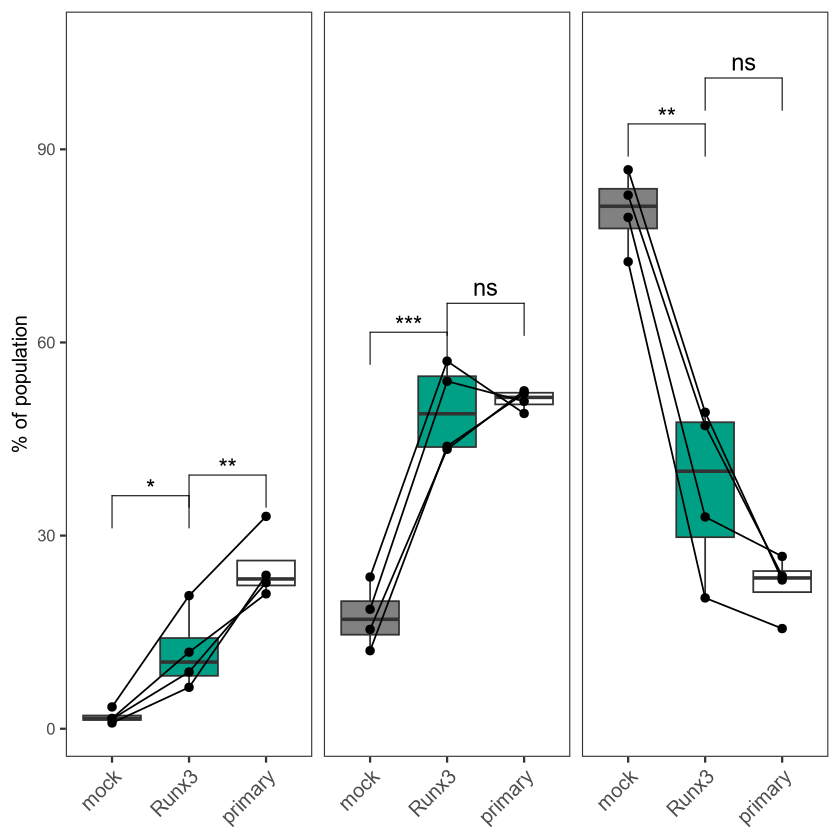

In [29]:
# Calculate p-values and BH-adjusted p-values for the Condition comparisons
plot.data.df <- subset %>% arrange(Population, ID)

plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = list(c("mock", "Runx3"), c("Runx3", "primary")),
    id_col = "ID",
    y_col = "Percent",
    x_col = "Condition",
    facet_col = "Population",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2024-001-Fig02g.csv")

p <- ggplot(plot.data.df, aes(x = Condition, y = Percent, fill = Condition)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Population, ncol = 3) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",
        tip.length = 0.05,
        size = 5,
        inherit.aes = FALSE
    ) + 
    ylim(c(min(subset$Percent) * 0.99, max(plot.stat.df$y.position, na.rm = TRUE) * 1.05)) +
    scale_fill_manual(values = c("mock" = "#808180", "Runx3" = "#00A087", "primary" = "#FFFFFF")) +
    ylab("% of population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

print(p)

In [30]:
pdf("2024-001-Fig02g.pdf", width = 4, height = 2)
print(p)
dev.off()

pdf 
  2

In [31]:
subset %>% 
  group_by(Condition, Population) %>% 
  summarise(Percent = mean(Percent)) %>% 
  ungroup()

`summarise()` has grouped output by 'Condition'. You can override using the
`.groups` argument.


Condition,Population,Percent
<fct>,<fct>,<dbl>
mock,Tcm,1.85179
mock,Tpm,17.42140
mock,Tem,80.41637
Runx3,Tcm,11.95326
Runx3,Tpm,49.58631
Runx3,Tem,37.36184
primary,Tcm,25.11714
primary,Tpm,51.09767
primary,Tem,22.29026
